<a href="https://colab.research.google.com/github/FarabiOnAMission/Machine-Learning-Stuffs/blob/main/Autograd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing the libraries**

In [40]:
import numpy as np

In [41]:
class Value:

  def __init__(self,data,_children=(),_op='',label=''):

    #checks if  the data is a n-dimensional numpy array
    if(isinstance(data,np.ndarray)):
      self.data = data
    else :
    #converts the data into np array
      self.data = np.array(data)

    #initializes the gradient with zeros with the same shape of the size of data
    self.grad = np.zeros_like(self.data)

    #placeholder for the backward function
    self._backward = lambda: None


    #set of previous nodes
    self._prev = set(_children)

    #Operation associated with the current node
    self._op = _op

    #label for the current node
    self.label = label

  def __add__(self,other):
    #convert other to a value if it is not already
    other = other if isinstance(other, Value) else Value(other)

    # Create a new Value instance representing the addition operation
    out = Value(self.data + other.data, (self,other),'+')

    def _backward():
    #Calculate gradient using chain-rule and summing it for incoming different paths
      self.grad = self.grad + (1.0 * out.grad)
      other.grad = other.grad + (1.0 * out.grad)

    #Give back the backward to the backward property of the value
    out._backward = _backward

    return out

  def __mul__(self,other):
    #Convert other to a value if it is not already
    other = other if isinstance(other, Value) else Value(other)

    #Create a new value instance representing the multiplication operation
    out = Value(self.data * other.data, (self,other),'*')

    def _backward():
      #Calculate the gradients using the chain rule and update the gradients of the operands
      self.grad = self.grad + (other.data * out.grad)
      other.grad = other.grad + (self.data * out.grad)

    #Assign the backward function to the new instance
    out._backward = _backward

    return out

  def __pow__(self,other):
    #if the power is a scaler
    if isinstance(other,(int,float)):
      #calculates the forward prop
      out_data = np.power(self.data,other);
      out = Value(out_data,(self,),f'**{other}')

      #backward prop for scaler power
      def _backward():
      #derivative of x^n
        self.grad = self.grad + (other * np.power(self.data,other-1) * out.grad)
      out._backward = _backward
      return out

      #backward is the gradient for the next node , meaning self.grad becomes out.grad for the next node

    #if the power is a value , x^y
    elif isinstance(other,Value):
      out_data = np.power(self.data,other.data)
      out = Value(out_data,(self,other),f'**')

      def _backward():
        self.grad = self.grad + (other.data * np.power(self.data,other.data-1)) * out.grad
        other.grad = other.grad + (np.log(self.data) * np.power(self.data,other.data)) * out.grad

      out._backward = _backward
      return out
    else:
        raise TypeError("Unsupported operand type(s) for **: 'Value' and '{}'".format(type(other).__name__))

  def __radd__(self,other):
    return self+other

  def __rmul__(self,other):
    return self*other

  def __rdiv__(self,other):
    return self*other**-1

  def __neg__(self):
    return self*-1

  def __sub__(self,other):
    return self + (-other)

  def exp(self):
    # Compute the element-wise exponential of the Value instance
    x = self.data
    out = Value(np.exp(x),(self,),'exp')

    def _backward():
     # Calculate the gradients using the chain rule
      self.grad = self.grad + (out.data*out.grad)

    # Assign the backward function to the new Value instance
    out._backward = _backward
    return out

  def tanh(self):
    #computing the hyperbolic tangent of the Value Instance
    x = self.data
    t = np.tanh(x)
    out = Value(t,(self,),'tanh')

    def _backward():
      self.grad = self.grad + ((1-t**2)*out.grad)

    out._backward = _backward
    return out

  def backward(self):
    #Perform backpropagation to compute Gradients
    topo = []
    visited = set()

    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)

    #build the topological order of nodes
    build_topo(self)

    self.grad = np.ones_like(self.data)

    for node in reversed(topo):
      node._backward()

  def __repr__(self):
    # String representation of the Value instance
    return f"Value(data={self.data})"


In [50]:
from graphviz import Digraph

def trace(root):
    # Initialize empty sets for nodes and edges
    nodes, edges = set(), set()

    # Recursive function to build the set of nodes and edges
    def build(v):
        # If the current node is not in the set of nodes
        if v not in nodes:
            # Add the current node to the set of nodes
            nodes.add(v)

            # Iterate over the previous nodes (parents) of the current node
            for child in v._prev:
                # Add an edge from the previous node to the current node
                edges.add((child, v))

                # Recursively call build() on the previous node
                build(child)

    # Start building the set of nodes and edges from the root node
    build(root)

    # Return the set of nodes and edges
    return nodes, edges

In [51]:
def draw_dot(root):
    # Create a Digraph object with SVG format and set the graph attribute 'rankdir' to 'LR'
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    # Retrieve the nodes and edges from the root
    nodes, edges = trace(root)

    # Iterate over the nodes
    for n in nodes:
        uid = str(id(n))
        # Convert the data array to a string representation
        data_str = np.array2string(n.data, precision=4, separator=',', suppress_small=True)
        # Convert the gradient array to a string representation
        grad_str = np.array2string(n.grad, precision=4, separator=',', suppress_small=True)
        # Create the label for the node using the node's label, data, and gradient strings
        label = "{ %s | data %s | grad %s }" % (n.label, data_str, grad_str)
        # Add a node to the graph with a unique ID, label, and shape 'record'
        dot.node(name=uid, label=label, shape='record')

        # If the node has an operation associated with it
        if n._op:
            # Add a node to the graph with a unique ID based on the node's ID and operation, and label it with the operation
            dot.node(name=uid + n._op, label=n._op)
            # Add an edge from the operation node to the current node
            dot.edge(uid + n._op, uid)

    # Iterate over the edges
    for n1, n2 in edges:
        # Add an edge from the first node's ID to the second node's ID concatenated with the operation name
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    # Return the generated graph
    return dot

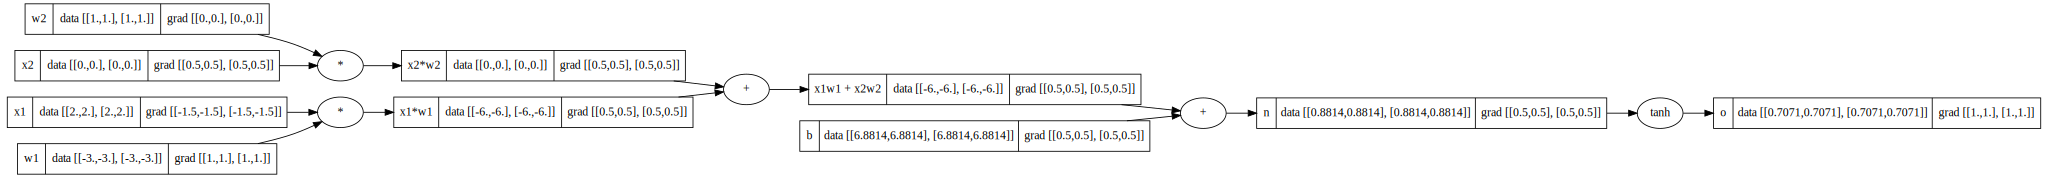

In [52]:
x1 = Value([[2.0,2.0],[2.0,2.0]],label="x1")
x2 = Value([[0.0,0.0],[0.0,0.0]],label="x2")

w1 = Value([[-3.0, -3.0], [-3.0, -3.0]], label="w1")
w2 = Value([[1.0, 1.0], [1.0, 1.0]], label="w2")

b = Value([[6.8813735870195432, 6.8813735870195432], [6.8813735870195432, 6.8813735870195432]], label="b")

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'


o = n.tanh();o.label = 'o'

o.backward()

draw_dot(o)